## AirFly Insights: Data Visualization and Analysis of Airline Operations Overview (Milestone4)

### Problem Statement:-
##### The objective of this project is to analyze large-scale airline flight data to uncover operational trends, delay patterns, and cancellation reasons using data visualization techniques. The goal is to help understand airline and airport-level performance and contribute to actionable insights using visual analysis.

In [1]:
#Importing all the libraries:-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#As the datatypes are not saved for the cleaned dataset in Python, :.Creating a use_datatypes funtion:-
def use_datatypes(df):
    data['FL_DATE']=pd.to_datetime(data['FL_DATE'])
    data['CANCELLED']=data['CANCELLED'].astype('int8')
    data['DIVERTED']=data['DIVERTED'].astype('int8')
    catg_col=['AIRLINE','AIRLINE_DOT','AIRLINE_CODE','ORIGIN','ORIGIN_CITY','DEST','DEST_CITY','CANCELLATION_CODE']
    for col in catg_col:
        data[col]=data[col].astype('category')
    minu_col=['DEP_DELAY','ARR_DELAY','TAXI_IN','TAXI_OUT','CRS_ELAPSED_TIME','ELAPSED_TIME','AIR_TIME','DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
    for col in minu_col:
        data[col]=data[col].astype('float32')
    hhmm_col=['CRS_DEP_TIME','DEP_TIME','CRS_ARR_TIME','ARR_TIME','WHEELS_OFF','WHEELS_ON']
    for col in hhmm_col:
        data[col]=data[col].astype('Int32')
    data['DISTANCE']=data['DISTANCE'].astype('float32')
    data['DOT_CODE']=data['DOT_CODE'].astype('int32')
    data['FL_NUMBER']=data['FL_NUMBER'].astype('int32')
    data['DEP_HOUR']=data['DEP_HOUR'].astype('Int8')
    data['ROUTE']=data['ROUTE'].astype('category')
    data['YEAR']=data['YEAR'].astype('int32')
    data['MONTH']=data['MONTH'].astype('int8')
    data['MONTH_NAME']=data['MONTH_NAME'].astype('category')
    data['WEEKDAY']=data['WEEKDAY'].astype('category')
    return df

### Data Cleaning and Preparation:-

##### The dataset initially contained approximately 3 million rows and 32 columns, representing detailed airline operations data. A thorough understanding of each column was performed to interpret airline-specific variables and ensure correct analysis. 
##### Handling Missing Values:-  Missing values were observed in columns such as DEP_TIME, DEP_DELAY, TAXI_IN, TAXI_OUT, WHEELS_ON, and WHEELS_OFF, primarily due to cancelled or diverted flights. The Cancellation Code column contained a large number of null values (~2.9 million), which represented non-cancelled flights. These were replaced with “NC” (Not Cancelled) for clarity. Null values in delay-related columns were treated carefully, as they carry operational meaning rather than data absence.
##### Data Cleaning Decisions:- Rows with missing values in CRS Elapsed Time (scheduled duration) were identified as data entry issues and removed. A small number of inconsistent records (e.g., flights that departed but had no arrival or diversion status) were also removed to maintain data integrity. Duplicate records were checked, and no duplicates were found.
##### Handling Delay Values:- Flights with ARR_DELAY ≤ 0 (early or on-time arrivals) were considered as no delay, and delay related nulls in such cases were replaced with 0. Only valid delay scenarios were retained for accurate delay analysis.
##### Data Type Optimization:- Data types of columns were converted appropriately to optimize memory usage and improve processing efficiency.
##### Feature Engineering:- New features were created to enhance analysis, including: YEAR, MONTH, MONTH_NAME, WEEKDAY, ROUTE (ORIGIN–DEST pair)
##### Final Dataset:- After cleaning and preprocessing, the dataset contained approximately 2,999,984 records, ready for analysis.

In [24]:
data.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'YEAR', 'MONTH', 'MONTH_NAME', 'WEEKDAY',
       'DEP_HOUR', 'ROUTE', 'Holiday'],
      dtype='object')

In [3]:
data=pd.read_csv('cleaned_flights_sample.csv')
data.head(3)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,MONTH_NAME,WEEKDAY,DEP_HOUR,ROUTE
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,0.0,0.0,0.0,2019,1,January,Wednesday,11,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,0.0,0.0,0.0,2022,11,November,Saturday,21,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,0.0,0.0,0.0,2022,7,July,Friday,10,DEN-MSP


In [4]:
data=use_datatypes(data)

### KPI's (Key Performance Indicator) of the Project:-

In [5]:
#Total flight records:-
total_flights=data['FL_NUMBER'].count()
print('Total Number Of Flights: ',total_flights)

#Number of unique airlines:-
unique_airlines=data['AIRLINE'].nunique()
print('Unique Airlines: ',unique_airlines)

#Percentage of flights that got cancelled:-
cancelled_flights=round(((data['CANCELLED']==1).sum()/len(data))*100,2)
print(f'Cancelled Flights: {cancelled_flights:.2f}%')

#Percentage of flights that got diverted:-
diverted_flights=round(((data['DIVERTED']==1).sum()/len(data))*100,2)
print(f'Diverted Flights: {diverted_flights:.2f}%')

#Average Late Departure Delay:-
avg_latedep=round(data[(data['CANCELLED']==0) & (data['DEP_DELAY']>0)]['DEP_DELAY'].mean(),2)
print(f"Average Late Departure Delay: {avg_latedep} mins")

#Average Late Arrival Delay:-
avg_latearr=round(data[(data['CANCELLED']==0) & (data['ARR_DELAY']>0)]['ARR_DELAY'].mean(),2)
print(f"Average Late Arrival Delay: {avg_latearr} mins")

Total Number Of Flights:  2999984
Unique Airlines:  18
Cancelled Flights: 2.64%
Diverted Flights: 0.24%
Average Late Departure Delay: 39.459999084472656 mins
Average Late Arrival Delay: 39.75 mins


In [6]:
#Analysing the flights which take off as well as they are not diverted, means they reach at their destination
active_flights=data[(data['CANCELLED']==0) & (data['DIVERTED']==0)]
len(active_flights)

2913802

### Which month shows maximum flights activity?

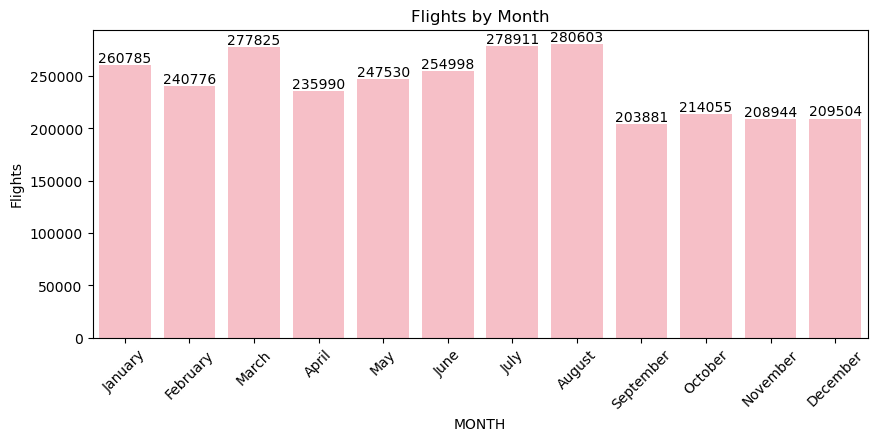

In [7]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
month_counts=active_flights['MONTH_NAME'].value_counts().reindex(month_order)
plt.figure(figsize=(10,4))
i=sns.barplot(x=month_counts.index,y=month_counts.values,color='lightpink')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Flights by Month')
plt.xlabel('MONTH')
plt.ylabel('Flights')
plt.xticks(rotation=45)
plt.savefig('FlightsbyMonth.png', dpi=300, bbox_inches='tight')
plt.show()


##### Flight activity peaks in August and July, indicating strong seasonal demand during mid-year travel periods. The month of Spetmeber shows less flights

### What are the Top 5 Airlines?

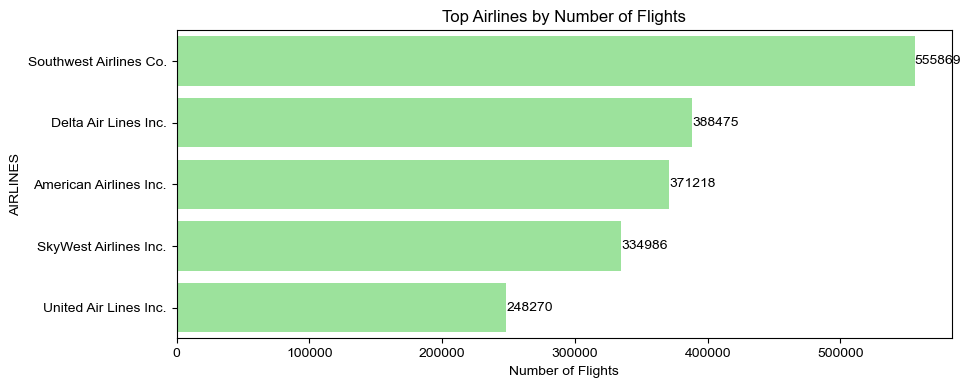

In [8]:
top_airlines=active_flights['AIRLINE'].value_counts().head(5)
plt.figure(figsize=(10,4))
i=sns.barplot(x=top_airlines.values,y=top_airlines.index,order=top_airlines.index,color='lightgreen')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('Number of Flights')
plt.ylabel('AIRLINES')
plt.title('Top Airlines by Number of Flights')
sns.set_style('white')
plt.show()

##### Southwest Airlines Co. at the top with ~5 lakh flights, Delta Air Lines and American Airlines with ~3 lakh flights.

### Which Routes are most travelled by the Flights?

In [18]:
active_flights['ROUTE']=active_flights['ROUTE'].astype('str')
top_dest=(active_flights['ROUTE'].value_counts().nlargest(10).reset_index())
top_dest.columns=['ROUTE','COUNT']
top_dest

,ROUTE,COUNT
0,SFO-LAX,5218
1,LAX-SFO,5072
2,OGG-HNL,4589
3,LAX-LAS,4540
4,LGA-ORD,4510
5,HNL-OGG,4489
6,LAS-LAX,4453
7,ORD-LGA,4403
8,LAX-JFK,4325
9,JFK-LAX,4232


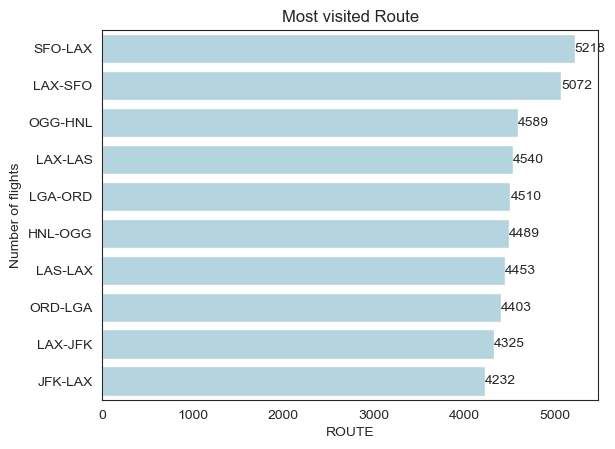

In [20]:
i=sns.barplot(x='COUNT',y='ROUTE',data=top_dest,color='lightblue')
for bars in i.containers:
    i.bar_label(bars)
plt.xlabel('ROUTE')
plt.ylabel('Number of flights')
plt.title('Most visited Route')
plt.show()

##### The SFO–LAX and LAX–SFO routes are the most frequently traveled, indicating high demand between San Francisco and Los Angeles.

### What is the averge Departure delay and Arrival delay across the Airlines?

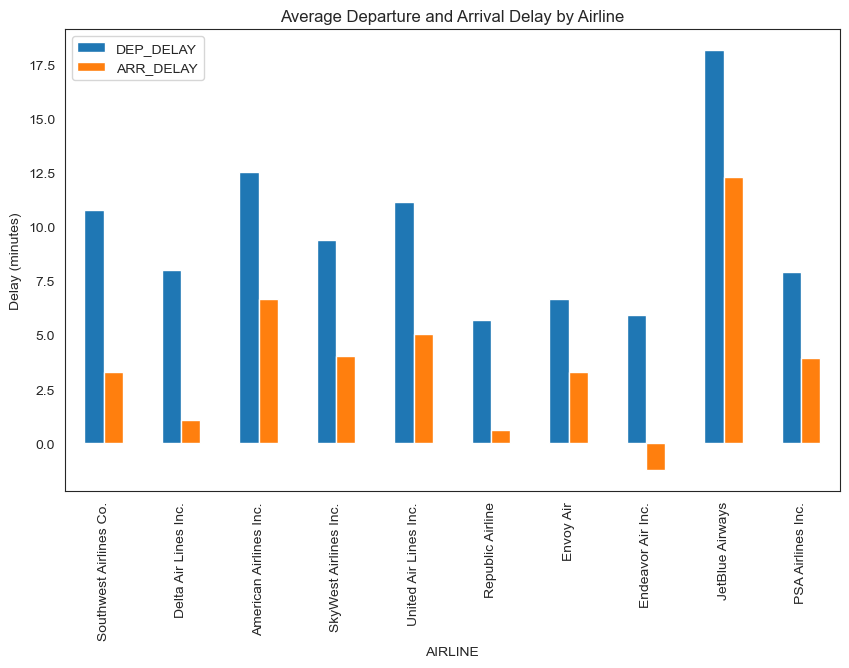

In [11]:
airline_delay = active_flights.groupby('AIRLINE').agg({
    'DEP_DELAY': 'mean',
    'ARR_DELAY': 'mean'
}).sort_values('ARR_DELAY', ascending=False)

top_airlines = active_flights['AIRLINE'].value_counts().head(10).index
airline_delay_top = airline_delay.loc[top_airlines]

airline_delay_top.plot(kind='bar', figsize=(10,6))
plt.title('Average Departure and Arrival Delay by Airline')
plt.ylabel('Delay (minutes)')
plt.savefig('AverageDepandArrDelay.png', dpi=300, bbox_inches='tight')
plt.show()

##### Avg DEP_DELAY is greater than ARR_DELAY acorss all the Airlines. So, flights depart late but arrive with less delay which means airlines try to make up the time during journey.

### What are the reasons for late Arrival or Delay in Arrival of the Flights?

In [12]:
delayed_flights=active_flights[active_flights['ARR_DELAY']>0]  #The delayed flights, arr_delay>0

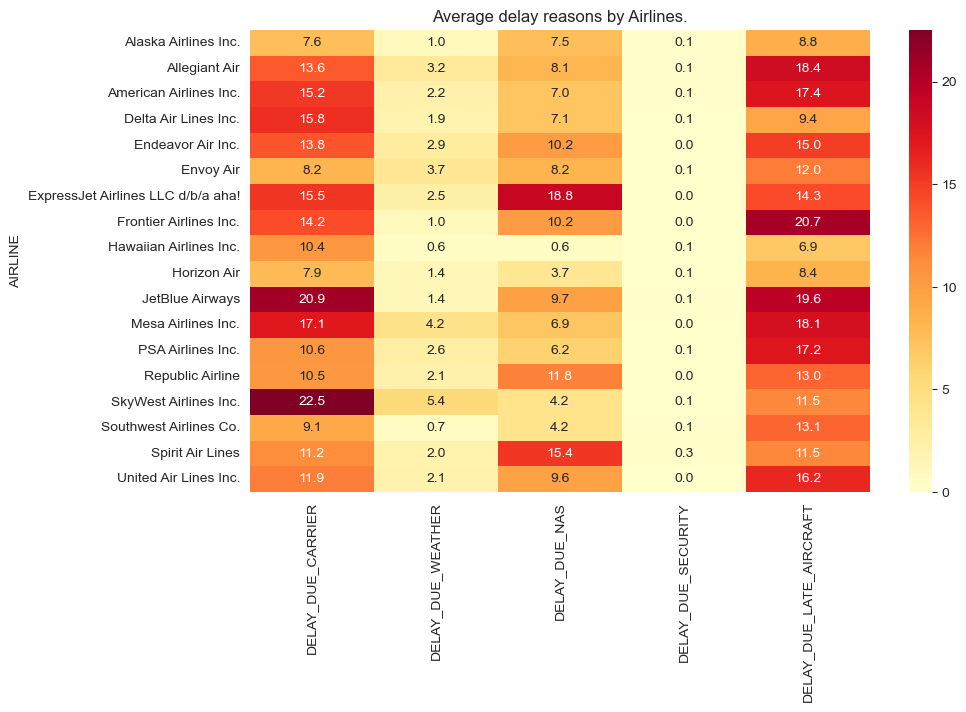

In [13]:
delay_reason_airline=delayed_flights.groupby('AIRLINE',observed=True)[['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']].mean()
plt.figure(figsize=(10,6))
sns.heatmap(delay_reason_airline,cmap='YlOrRd',annot=True,fmt='.1f')
plt.title('Average delay reasons by Airlines.')
plt.savefig('AvgDelayReasons.png', dpi=300, bbox_inches='tight')
plt.show()

##### Delays are mainly driven by carrier-related issues, followed by late aircraft and NAS (air traffic congestion), indicating both operational inefficiencies and traffic-related constraints.

### What is the Cancellation Rate in each Month?

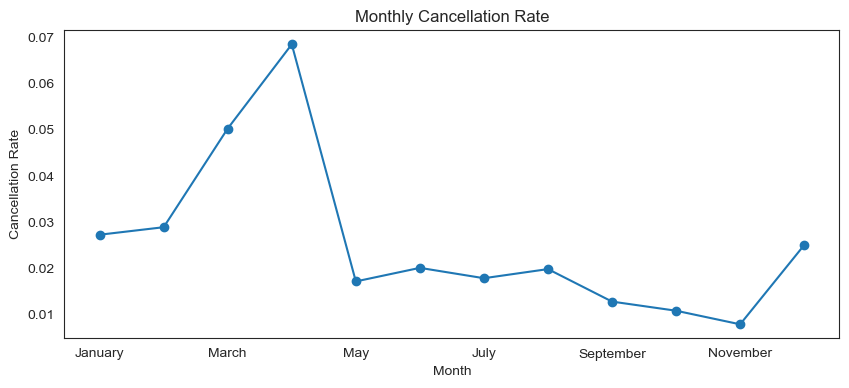

In [14]:
#Avg Cancellation of flights in each month
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_count=data.groupby('MONTH_NAME')['CANCELLED'].mean().reindex(month_order)

plt.figure(figsize=(10,4))
monthly_count.plot(kind='line',marker='o')
plt.title('Monthly Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.savefig('CancellationRate.png', dpi=300, bbox_inches='tight')
plt.show()

##### Flight cancellations peak during March and April, while November records the lowest cancellation rates.

### What are the reasons for Flight Cancellations?

In [15]:
#Cancelled flights:-
cancelled_flights=data[data['CANCELLED']==True]
len(cancelled_flights)

79126

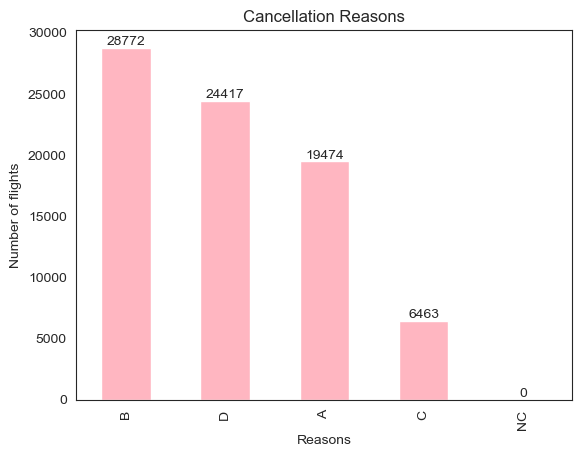

In [16]:
#Cancellation types:-
cancel_types=cancelled_flights['CANCELLATION_CODE'].value_counts()
i=cancel_types.plot(kind='bar',color='lightpink')
for bars in i.containers:
    i.bar_label(bars)
plt.title('Cancellation Reasons')
plt.xlabel('Reasons')
plt.ylabel('Number of flights')
plt.savefig('CancellationReasons.png', dpi=300, bbox_inches='tight')
plt.show()

##### Cancellation analysis shows that most flights were cancelled due to weather and security issues. Here, A represents Carrier-related cancellation, B represents Weather, C represents NAS (air traffic system), D represents Security, and NC indicates flights that were not cancelled.

### What is the impact of cancellations on holidays (the month of November and December)?

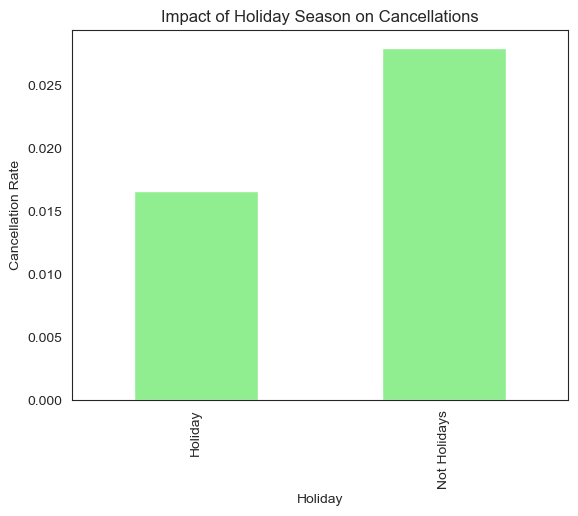

In [17]:
data['Holiday']=data['MONTH'].apply(lambda x: 'Holiday' if x in [11,12] else 'Not Holidays')
holiday_impact=data.groupby('Holiday')['CANCELLED'].mean()
holiday_impact.plot(kind='bar',color='lightgreen')
plt.title('Impact of Holiday Season on Cancellations')
plt.ylabel('Cancellation Rate')
plt.show()

##### Flight cancellation rates are lower during holiday months compared to non-holiday periods, indicating improved operational stability during peak travel times.

### Key Findings:-

##### The analysis of airline operations reveals that overall performance remains stable, with a low cancellation rate of approximately 2.6%, indicating that the majority of flights operate as scheduled. Among all airlines, Southwest Airlines dominates in terms of flight volume, operating the highest number of flights.
##### Flight demand shows clear seasonal patterns, with peak activity observed during July, August, and March, while September records the lowest traffic.Additionally, weekdays such as Friday, Monday, and Thursday experience higher travel activity, whereas Saturdays are comparatively less busy.
##### In terms of operational performance, JetBlue Airways and ExpressJet Airlines report the highest average arrival delays, with delays exceeding 50 minutes. It is also observed that departure delays are generally higher than arrival delays, suggesting that airlines are able to recover some lost time during transit.
##### Delay analysis further indicates that carrier-related issues are the primary cause of delays, followed by NAS (air traffic congestion), weather conditions, and late aircraft delays. Although flight diversions are relatively rare (~0.23%), airlines such as Southwest and SkyWest show slightly higher instances compared to others.
##### Route-level analysis highlights that the SFO–LAX and LAX–SFO routes are the most frequently traveled, indicating strong demand between major city pairs. However, certain routes such as FOD–DEN and DEN–ABE experience higher delays, mainly due to operational and carrier-related factors. Additionally, major airports such as ATL, DFW, and ORD emerge as the busiest hubs.
##### From a disruption perspective, flight cancellations peak during March and April, while November records the lowest cancellation rates. The primary causes of cancellations are identified as weather and security-related issues. Interestingly, cancellation rates during holiday months such as November and December are relatively lower, suggesting improved operational stability during peak travel periods.

#### Note:- The dataset still contains null values in columns such as DEP_DELAY, DEP_TIME, TAXI_IN, TAXI_OUT, WHEELS_ON, and WHEELS_OFF. These missing values are primarily associated with cancelled or diverted flights, where actual flight operations did not occur. The dataset still contains null values in columns such as DepDelay, DepTime, TaxiIn, TaxiOut, WheelsOn, and WheelsOff. These missing values are primarily associated with cancelled or diverted flights, where actual flight operations did not occur.